
ROOT NODE COUNTS
Play
Yes    9
No     5
Name: count, dtype: int64
Root Entropy  = 0.9403
Root Gini     = 0.4592

ID3-style (multiway) INFORMATION GAIN at ROOT
Outlook   IG = 0.2467   (weighted entropy after split = 0.6935)
Temp      IG = 0.0292   (weighted entropy after split = 0.9111)
Humidity  IG = 0.1518   (weighted entropy after split = 0.7885)
Wind      IG = 0.0481   (weighted entropy after split = 0.8922)

CART-style (multiway) GINI REDUCTION at ROOT
Outlook   ΔGini = 0.1163 (weighted gini after split = 0.3429)
Temp      ΔGini = 0.0187 (weighted gini after split = 0.4405)
Humidity  ΔGini = 0.0918 (weighted gini after split = 0.3673)
Wind      ΔGini = 0.0306 (weighted gini after split = 0.4286)

SKLEARN TREE (criterion=entropy) RULES
|--- Outlook_Overcast <= 0.50
|   |--- Humidity_Normal <= 0.50
|   |   |--- Outlook_Rain <= 0.50
|   |   |   |--- class: 0
|   |   |--- Outlook_Rain >  0.50
|   |   |   |--- Wind_Strong <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Wind_Stro

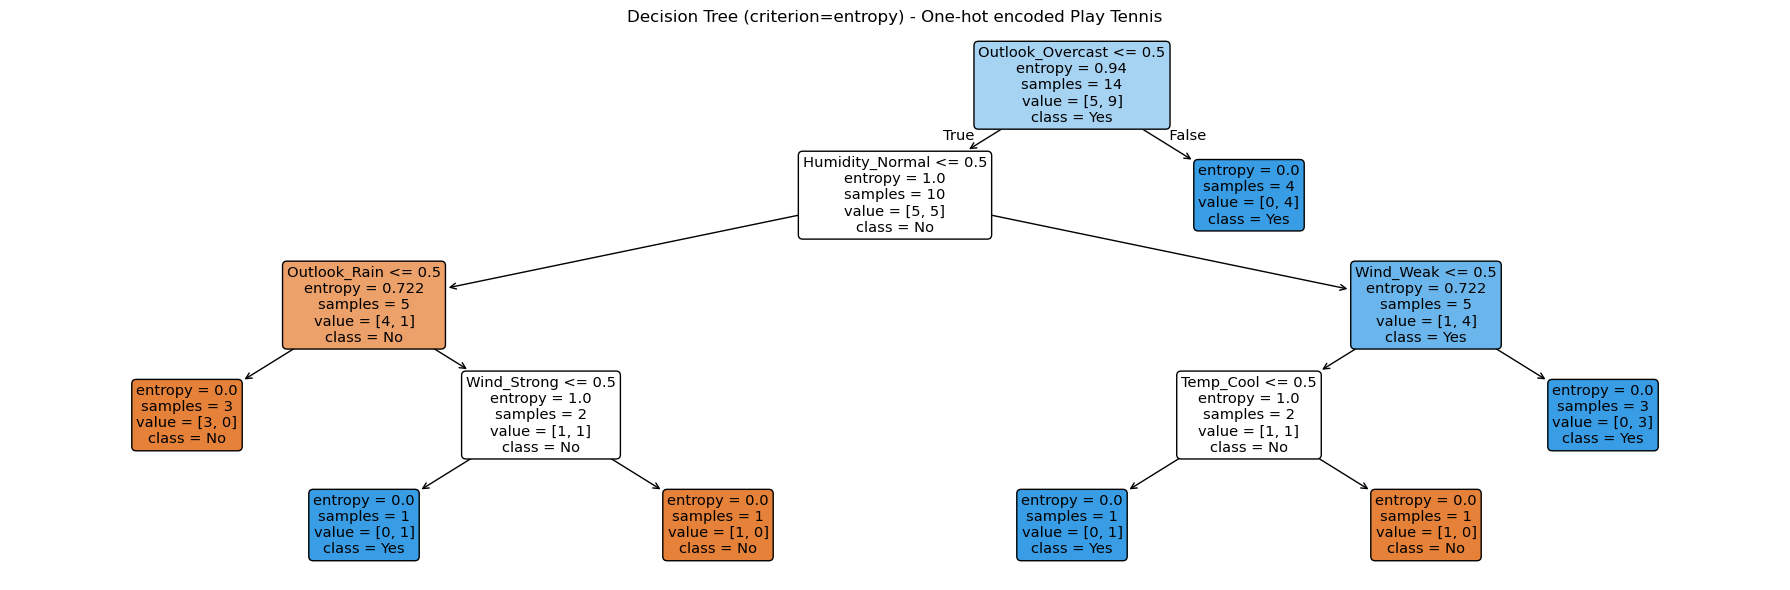

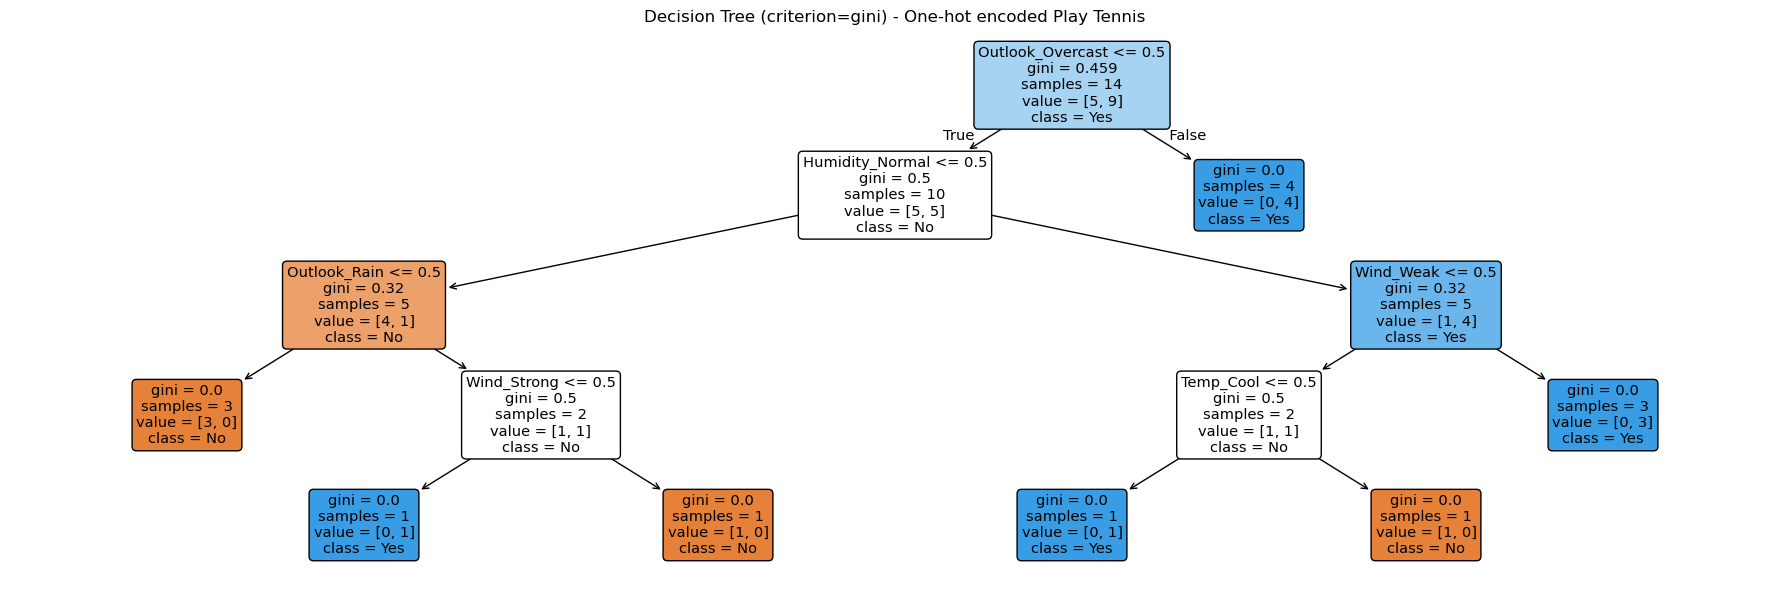

'\nTip:\n- If you specifically want the *multiway ID3 tree exactly* (Outlook -> {Sunny,Overcast,Rain}),\n  we can also code a small ID3 builder manually (no sklearn).\n- sklearn with one-hot encoding may choose splits in a slightly different order, but it will\n  learn the same logic on this dataset.\n'

In [1]:
"""
Decision Tree (Entropy/Information Gain) and (Gini) on the classic Play Tennis dataset
- Builds the dataset exactly as in the numerical illustration
- Computes:
    1) Root entropy + IG for each feature (multiway, ID3-style)
    2) Root gini + Δgini for each feature (multiway, CART-style impurity reduction)
    3) Builds a decision tree using scikit-learn with:
         - criterion="entropy" (or "log_loss" depending on sklearn version)
         - criterion="gini"
- Prints the learned rules and optionally plots the trees (if graphviz is available)

Run:
    python decision_tree_play_tennis.py or directly in a notebook cell.
"""

import math
import pandas as pd
import numpy as np

# ----------------------------
# 1) Dataset (same as illustration)
# ----------------------------
data = [
    (1,  "Sunny",    "Hot",  "High",   "Weak",   "No"),
    (2,  "Sunny",    "Hot",  "High",   "Strong", "No"),
    (3,  "Overcast", "Hot",  "High",   "Weak",   "Yes"),
    (4,  "Rain",     "Mild", "High",   "Weak",   "Yes"),
    (5,  "Rain",     "Cool", "Normal", "Weak",   "Yes"),
    (6,  "Rain",     "Cool", "Normal", "Strong", "No"),
    (7,  "Overcast", "Cool", "Normal", "Strong", "Yes"),
    (8,  "Sunny",    "Mild", "High",   "Weak",   "No"),
    (9,  "Sunny",    "Cool", "Normal", "Weak",   "Yes"),
    (10, "Rain",     "Mild", "Normal", "Weak",   "Yes"),
    (11, "Sunny",    "Mild", "Normal", "Strong", "Yes"),
    (12, "Overcast", "Mild", "High",   "Strong", "Yes"),
    (13, "Overcast", "Hot",  "Normal", "Weak",   "Yes"),
    (14, "Rain",     "Mild", "High",   "Strong", "No"),
]

df = pd.DataFrame(data, columns=["ID", "Outlook", "Temp", "Humidity", "Wind", "Play"])
features = ["Outlook", "Temp", "Humidity", "Wind"]
target = "Play"

# ----------------------------
# 2) Impurity functions
# ----------------------------
def entropy(labels):
    """Entropy H(S) = -sum p log2 p"""
    counts = pd.Series(labels).value_counts()
    total = counts.sum()
    ent = 0.0
    for c in counts:
        p = c / total
        ent -= p * math.log(p, 2)
    return ent

def gini(labels):
    """Gini(S) = 1 - sum p^2"""
    counts = pd.Series(labels).value_counts()
    total = counts.sum()
    s = 0.0
    for c in counts:
        p = c / total
        s += p * p
    return 1.0 - s

def weighted_impurity_after_split(df_node, feature, impurity_fn, target_col="Play"):
    """Multiway split: sum_v (|Sv|/|S|) * impurity(Sv)"""
    total = len(df_node)
    w = 0.0
    for val, group in df_node.groupby(feature):
        w += (len(group) / total) * impurity_fn(group[target_col])
    return w

def information_gain(df_node, feature, target_col="Play"):
    """IG = H(parent) - weighted_entropy(children)"""
    parent = entropy(df_node[target_col])
    after = weighted_impurity_after_split(df_node, feature, entropy, target_col)
    return parent - after

def gini_reduction(df_node, feature, target_col="Play"):
    """ΔGini = G(parent) - weighted_gini(children)"""
    parent = gini(df_node[target_col])
    after = weighted_impurity_after_split(df_node, feature, gini, target_col)
    return parent - after

# ----------------------------
# 3) Print root calculations (same style as your illustration)
# ----------------------------
print("\n==============================")
print("ROOT NODE COUNTS")
print("==============================")
print(df[target].value_counts())
print(f"Root Entropy  = {entropy(df[target]):.4f}")
print(f"Root Gini     = {gini(df[target]):.4f}")

print("\n==============================")
print("ID3-style (multiway) INFORMATION GAIN at ROOT")
print("==============================")
for f in features:
    ig = information_gain(df, f, target)
    after = weighted_impurity_after_split(df, f, entropy, target)
    print(f"{f:8s}  IG = {ig:.4f}   (weighted entropy after split = {after:.4f})")

print("\n==============================")
print("CART-style (multiway) GINI REDUCTION at ROOT")
print("==============================")
for f in features:
    dg = gini_reduction(df, f, target)
    after = weighted_impurity_after_split(df, f, gini, target)
    print(f"{f:8s}  ΔGini = {dg:.4f} (weighted gini after split = {after:.4f})")

# ----------------------------
# 4) Build sklearn trees (entropy and gini)
#    Note: sklearn needs numeric features -> one-hot encode categorical variables
# ----------------------------
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text

X = df[features]
y = df[target].map({"No": 0, "Yes": 1}).astype(int)

X_onehot = pd.get_dummies(X, drop_first=False)  # keep all to match pure logic
feature_names = X_onehot.columns.tolist()

# Train on full data (since this is an illustration)
X_train, X_test, y_train, y_test = X_onehot, X_onehot, y, y

def build_tree(criterion_name):
    # sklearn versions:
    # - older: criterion="entropy"
    # - newer: "entropy" still works; also "log_loss" exists
    tree = DecisionTreeClassifier(criterion=criterion_name, random_state=0)
    tree.fit(X_train, y_train)
    return tree

# Entropy tree
try:
    tree_entropy = build_tree("entropy")
    entropy_criterion_used = "entropy"
except ValueError:
    # fallback if some environment only supports log_loss
    tree_entropy = build_tree("log_loss")
    entropy_criterion_used = "log_loss"

tree_gini = build_tree("gini")

print("\n==============================")
print(f"SKLEARN TREE (criterion={entropy_criterion_used}) RULES")
print("==============================")
print(export_text(tree_entropy, feature_names=feature_names))

print("\n==============================")
print("SKLEARN TREE (criterion=gini) RULES")
print("==============================")
print(export_text(tree_gini, feature_names=feature_names))

# ----------------------------
# 5) Predict a sample (same as earlier example)
#    Example: Outlook=Sunny, Humidity=High, Wind=Weak, Temp=Mild -> expect No
# ----------------------------
sample = pd.DataFrame([{
    "Outlook": "Sunny",
    "Temp": "Mild",
    "Humidity": "High",
    "Wind": "Weak"
}])
sample_onehot = pd.get_dummies(sample, drop_first=False).reindex(columns=feature_names, fill_value=0)

pred_entropy = tree_entropy.predict(sample_onehot)[0]
pred_gini = tree_gini.predict(sample_onehot)[0]

print("\n==============================")
print("SAMPLE PREDICTION")
print("==============================")
print("Sample:", sample.iloc[0].to_dict())
print("Prediction (Entropy tree):", "Yes" if pred_entropy == 1 else "No")
print("Prediction (Gini tree):   ", "Yes" if pred_gini == 1 else "No")

# ----------------------------
# 6) Optional: plot tree (requires matplotlib)
# ----------------------------
try:
    import matplotlib.pyplot as plt
    from sklearn.tree import plot_tree

    plt.figure(figsize=(18, 6))
    plot_tree(tree_entropy, feature_names=feature_names, class_names=["No", "Yes"], filled=True, rounded=True)
    plt.title(f"Decision Tree (criterion={entropy_criterion_used}) - One-hot encoded Play Tennis")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(18, 6))
    plot_tree(tree_gini, feature_names=feature_names, class_names=["No", "Yes"], filled=True, rounded=True)
    plt.title("Decision Tree (criterion=gini) - One-hot encoded Play Tennis")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("\n[Plot skipped]", e)

"""
Tip:
- If you specifically want the *multiway ID3 tree exactly* (Outlook -> {Sunny,Overcast,Rain}),
  we can also code a small ID3 builder manually (no sklearn).
- sklearn with one-hot encoding may choose splits in a slightly different order, but it will
  learn the same logic on this dataset.
"""
